# ABI

$\Xi$

## Forward-симулятор рынка

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from tqdm import tqdm

In [56]:
def prospect_value_function(x: float, alpha=0.8, beta=0.8, lam=2.25) -> float:
    if x >= 0:
        return x ** alpha
    
    return -lam * ((-x) ** beta)

In [57]:
def prospect_np(x: np.array, alpha: float=0.8, beta: float=0.8, lam: float=2.25) -> np.array:
    res = np.zeros_like(x, dtype=float)

    pos = x >= 0
    neg = x < 0

    res[pos] = x[pos] ** alpha
    res[neg] = -lam * ((-x[neg]) ** beta)

    return res

In [58]:
def softmax(x: np.array) -> np.array:
    exp_input = np.exp(x)
    exp_input_sum = np.sum(exp_input)

    return exp_input / exp_input_sum

In [59]:
class Provider:
    def __init__(self, name: str, p: np.array):
        self.name = name
        self.p = p

    def __repr__(self):
        return f"Provider '{self.name}': {self.p}"

In [60]:
class Agent:
    def __init__(self, w: np.array, ref: np.array, directions: np.array):
        self.w = w 
        self.ref = ref
        self.directions = directions
        self.current_provider = -1
        self.switching_cost = 0

    def utility_for(self, option: np.array):
        deltas = (option - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)

        return (prospect_activation @ self.w).item()
    
    def utility_for_matrix(self, options: np.array):
        deltas = (options - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)
        utilities = prospect_activation @ self.w
        return utilities.flatten()

    
    def activated_output_for(self, providers: List[Provider], actiavtion_func) -> np.array:
        utilities = np.array([self.utility_for(provider.p) for provider in providers])
        return actiavtion_func(utilities)
    
    def __repr__(self):
        return f"Agent[w={np.round(self.w, 2)}, ref={np.round(self.ref, 2)}, sw_cost={self.switching_cost}, current_provider={self.current_provider}]"

In [61]:
rules = {
    'price': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
    'connection_speed': {
        'min': 0,
        'max': 1_000,
        'expected': 100,
        'std': 15
    },
    'quality': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
}

def normalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return (value - mn) / (mx - mn)

def clip_to_bounds(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return float(np.clip(value, mn, mx))

In [62]:
def utility_range(agents: List[Agent], providers: List[Provider]):
    values = np.zeros(len(agents) * len(providers))
    idx = 0
    for agent in agents:
        for provider in providers:
            u = agent.utility_for(provider.p)
            values[idx] = u
            idx += 1

    return np.round(values.min(), 3), np.round(values.max(), 3), np.round(values.std(), 3)

In [63]:
def init_agents(amount: int, providers: List[Provider]) -> List[Agent]:
    weights = np.array([0.15, 0.25, 0.3]) / 0.7
    directions = np.array([-1, 1, 1])
    res = []

    for _ in range(amount):
        price_ref = np.random.normal(rules['price']['expected'], rules['price']['std'])
        speed_ref = np.random.normal(rules['connection_speed']['expected'], rules['connection_speed']['std'])
        quality_ref = np.random.normal(rules['quality']['expected'], rules['quality']['std'])

        price_ref = clip_to_bounds(price_ref, 'price')
        speed_ref = clip_to_bounds(speed_ref, 'connection_speed')
        quality_ref = clip_to_bounds(quality_ref, 'quality')

        ref = np.array([
            normalize(price_ref, 'price'),
            normalize(speed_ref, 'connection_speed'),
            normalize(quality_ref, 'quality')
        ])

        res.append(Agent(weights, ref, directions))

    sample_agents = np.random.choice(res, amount // 5)
    u_min, u_max, u_std = utility_range(sample_agents, providers)
    u_range = u_max - u_min

    print(f"Utility function: min={u_min}, max={u_max}, std={u_std}. Range={u_range}")

    for agent in res:
        agent.switching_cost = np.random.normal(u_std, 0.3 * u_std)

    return res


In [64]:
def init_providers() -> List[Provider]:
    res = []

    res.append(Provider("Wir", np.array(
        [
            normalize(70, 'price'),
            normalize(600, 'connection_speed'),
            normalize(70, 'quality')
        ])))
    
    res.append(Provider("Competitior1", np.array(
        [
            normalize(40, 'price'),
            normalize(100, 'connection_speed'),
            normalize(40, 'quality')
        ])))
    
    res.append(Provider("Competitior2", np.array(
        [
            normalize(90, 'price'),
            normalize(900, 'connection_speed'),
            normalize(75, 'quality')
        ])))

    return res

In [65]:
providers = init_providers()

providers

[Provider 'Wir': [0.7 0.6 0.7],
 Provider 'Competitior1': [0.4 0.1 0.4],
 Provider 'Competitior2': [0.9  0.9  0.75]]

In [66]:
M = 10_000
T = 104
LR = 0.1

In [67]:
agents = init_agents(M, providers)

agents[0:5]

Utility function: min=-0.662, max=0.508, std=0.206. Range=1.17


[Agent[w=[0.21 0.36 0.43], ref=[0.53 0.11 0.58], sw_cost=0.1965158109246264, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.65 0.1  0.69], sw_cost=0.24667713366552804, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.52 0.11 0.62], sw_cost=0.24693899283719054, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.5  0.11 0.43], sw_cost=0.3378326295725155, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.77 0.11 0.6 ], sw_cost=0.22486213839245317, current_provider=-1]]

In [68]:
agent = agents[0]
for p in providers:
    print(agent.utility_for(p.p))
print(agent.activated_output_for(providers, softmax))

0.16364492728217614
-0.22673057425945392
0.18198310368026271
[0.37101483 0.25110383 0.37788133]


In [69]:
class Simulator:
    def __init__(self, T: int, LR: float):
        self.T = T
        self.LR = LR

    @staticmethod
    def __find_equilibrium_step(history, window=20, eps=1e-2, patience=4):
        T, N = history.shape
        stable_count = 0

        for t in range(2 * window, T):
            prev_mean = history[t - 2 * window : t - window].mean(axis=0)
            curr_mean = history[t - window : t].mean(axis=0)

            shift = np.max(np.abs(curr_mean - prev_mean))

            if shift < eps:
                stable_count += 1
                if stable_count >= patience:
                    return t - window, curr_mean
            else:
                stable_count = 0

        return None, history[-window:].mean(axis=0)

    def run(self, agents, providers):
        M = len(agents)

        market_share_history = np.zeros(shape=(self.T, len(providers)))
        providers_idxes = np.arange(0, len(providers))
        provider_options = np.array([provider.p for provider in providers])

        for t in tqdm(range(self.T)):
            agent_choices = np.zeros(shape=len(providers))

            for agent in agents:
                utilities = agent.utility_for_matrix(provider_options)
                if agent.current_provider != -1:
                    utilities -= agent.switching_cost
                    utilities[agent.current_provider] += agent.switching_cost

                logit_probs = softmax(utilities)

                choice = np.random.choice(providers_idxes, p=logit_probs)
                agent_choices[choice] += 1
                provider = providers[choice]
                agent.ref = (1 - self.LR) * agent.ref + self.LR * provider.p
                agent.current_provider = choice
            
            market_share_history[t] = agent_choices / M

        eq_step, eq_shares = Simulator.__find_equilibrium_step(market_share_history)

        return eq_step, eq_shares, market_share_history


In [70]:
class VectorizedSimulator:
    def __init__(self, T: int, LR: float):
        self.T = T
        self.LR = LR
        self.rng = np.random.default_rng()

    @staticmethod
    def __find_equilibrium_step(history, window=20, eps=1e-2, patience=4):
        T, N = history.shape

        pad = np.vstack([np.zeros((1, N), dtype=history.dtype), np.cumsum(history, axis=0)])
        window_means = (pad[window:] - pad[:-window]) / window  # (T-window+1, N)

        shifts = np.max(np.abs(window_means[window:] - window_means[:-window]), axis=1)

        stable_count = 0
        for i, shift in enumerate(shifts, start=2 * window - 1):
            if shift < eps:
                stable_count += 1
                if stable_count >= patience:
                    eq_step = i - window + 1
                    return eq_step, window_means[eq_step]
            else:
                stable_count = 0

        return None, window_means[-1]
    
    def __gumbel_random_choice(self, utilities: np.array) -> int:
        U = self.rng.random(utilities.shape, dtype=np.float32)
        U = np.clip(U, 1e-8, 1 - 1e-8)
        gumbel_noise = -np.log(-np.log(U))
        return np.argmax(utilities + gumbel_noise, axis=1)

    def run(self, agents, providers):
        M = len(agents)
        P = len(providers)

        market_share_history = np.zeros((self.T, P), dtype=np.float32)

        provider_options = np.ascontiguousarray(
            np.stack([p.p for p in providers]).astype(np.float32)
        )

        refs = np.ascontiguousarray(np.stack([a.ref for a in agents]).astype(np.float32))
        current = np.array([a.current_provider for a in agents], dtype=np.int32)
        switch_cost = np.array([a.switching_cost for a in agents], dtype=np.float32)

        weights = np.asarray(agents[0].w, dtype=np.float32).reshape(-1)
        directions = np.asarray(agents[0].directions, dtype=np.float32).reshape(-1)

        for t in range(self.T):
            deltas = (provider_options[None, :, :] - refs[:, None, :]) * directions[None, None, :]
            activation = prospect_np(deltas)
            utilities = np.tensordot(activation, weights, axes=([2], [0]))  # (M, P)

            utilities -= switch_cost[:, None]

            valid = current >= 0
            rows = np.nonzero(valid)[0]
            utilities[rows, current[valid]] += switch_cost[valid]

            choices = self.__gumbel_random_choice(utilities)           

            counts = np.bincount(choices, minlength=P).astype(np.float32)
            market_share_history[t] = counts / M

            refs = (1 - self.LR) * refs + self.LR * provider_options[choices]
            current = choices.astype(np.int32)

        eq_step, eq_shares = VectorizedSimulator.__find_equilibrium_step(market_share_history)
        return eq_step, eq_shares, market_share_history


In [71]:
simulator = VectorizedSimulator(T, 0.2)

eq_step, eq_shares, market_share_history = simulator.run(agents, providers)

print(f"Equilibrium occurred on step: {eq_step}. Equilibrium market shares: {np.round(eq_shares, 2)}")

Equilibrium occurred on step: 26. Equilibrium market shares: [0.39 0.18 0.43]


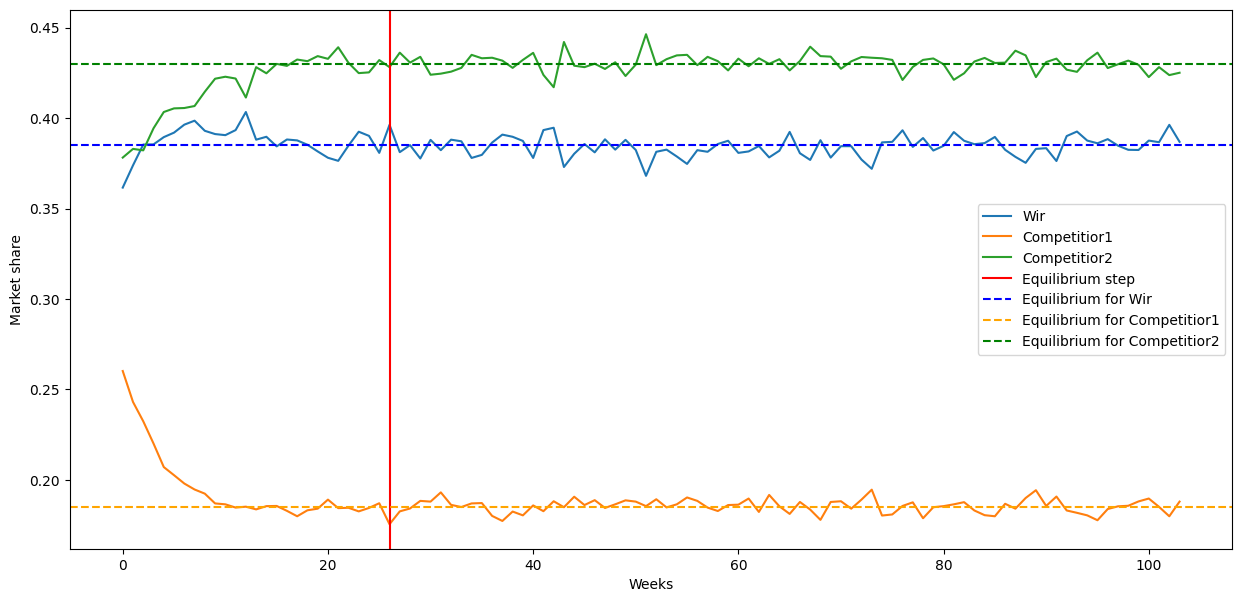

In [72]:
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(15, 7))

plt.plot(market_share_history, label=list(map(lambda x: x.name, providers)))

plt.axvline(eq_step, color='red', label='Equilibrium step')

for i, sh in enumerate(eq_shares):
    plt.axhline(sh, linestyle='dashed', linewidth=1.5, label=f'Equilibrium for {providers[i].name}', color=colors[i])

plt.xlabel("Weeks")
plt.ylabel("Market share")
plt.legend()

## Оптимизация равновесного состояния

Проблема: симулятор рынка стохастический. Классические методы оптимизации (вроде SGD) тут работать не будут, поскольку нет аналитических выражений и градиентов.

Приходим к задаче blackbox оптимизации: попробуем решить её с использованием Evolution strategy.

In [ ]:
class MarketLoss:
    def __init__(self, target_share: np.ndarray):
        self.target_share = np.asarray(target_share, dtype=np.float32)

    def __call__(self, market_share: np.ndarray) -> float:
        return float(np.linalg.norm(market_share - self.target_share))


### ScenarioSampler 

Его задача - генерировать сценарии рынка $\varphi$

In [ ]:
class ScenarioSampler:
    def __init__(self, base_phi: np.ndarray, sigma: np.ndarray):
        self.phi = np.asarray(base_phi, dtype=np.float32)
        self.sigma = np.asarray(sigma, dtype=np.float32)

    def sample_population(self, n: int, mirrored: bool = True) -> np.ndarray:
        d = self.phi.shape[0]

        if mirrored:
            half = n // 2
            eps = np.random.normal(size=(half, d)).astype(np.float32)
            eps = np.vstack([eps, -eps])
            if n % 2 == 1:
                extra = np.random.normal(size=(1, d)).astype(np.float32)
                eps = np.vstack([eps, extra])
        else:
            eps = np.random.normal(size=(n, d)).astype(np.float32)

        return self.phi[None, :] + self.sigma[None, :] * eps

    def update(self, grad: np.ndarray, lr: float):
        self.phi -= lr * grad


In [ ]:
sampler = ScenarioSampler()

### Generator

Он хранит $\xi$ и двигает его в сторону уменьшения loss

In [ ]:
class Generator:
    def __init__(self, base_xi: np.ndarray, sigma: np.ndarray):
        self.xi = np.asarray(base_xi, dtype=np.float32)
        self.sigma = np.asarray(sigma, dtype=np.float32)

    def sample_population(self, n: int, mirrored: bool = True) -> np.ndarray:
        d = self.xi.shape[0]

        if mirrored:
            half = n // 2
            eps = np.random.normal(size=(half, d)).astype(np.float32)
            eps = np.vstack([eps, -eps])
            if n % 2 == 1:
                extra = np.random.normal(size=(1, d)).astype(np.float32)
                eps = np.vstack([eps, extra])
        else:
            eps = np.random.normal(size=(n, d)).astype(np.float32)

        return self.xi[None, :] + self.sigma[None, :] * eps

    def update(self, grad: np.ndarray, lr: float):
        self.xi -= lr * grad


### Оценка эволюционного градиента

In [ ]:
def evolution_gradient(base: np.ndarray,
                       population: np.ndarray,
                       losses: np.ndarray,
                       sigma: np.ndarray) -> np.ndarray:
    """
    Оценка градиента для минимума по antithetic sampling.
    base: (d,)
    population: (n, d)
    losses: (n,)
    sigma: (d,)
    """
    eps = (population - base[None, :]) / sigma[None, :]
    losses = losses.astype(np.float32)

    # нормализация уменьшает дисперсию оценки
    losses = (losses - losses.mean()) / (losses.std() + 1e-8)

    grad = np.mean(losses[:, None] * eps, axis=0)
    return grad


### Каркас обучения

In [ ]:
def evaluate_candidate(simulator, loss_fn, xi, phi, build_providers, build_agents):
    providers = build_providers(xi, phi)
    agents = build_agents(phi)

    eq_step, eq_shares, history = simulator.run(agents, providers)
    loss = loss_fn(eq_shares)

    return loss, eq_step, eq_shares, history


In [ ]:
def train_adversarial(
    simulator,
    generator,
    discriminator,
    loss_fn,
    build_providers,
    build_agents,
    outer_steps: int = 200,
    pop_size_xi: int = 16,
    pop_size_phi: int = 16,
    lr_g: float = 0.05,
    lr_d: float = 0.05,
):
    history = {
        "gen_loss": [],
        "disc_loss": [],
        "xi": [],
        "phi": [],
        "eq_share": [],
    }

    for step in range(outer_steps):
        # --- 1) discriminator updates: ищем худшие сценарии рынка ---
        phi_pop = discriminator.sample_population(pop_size_phi, mirrored=True)

        disc_losses = []
        for phi in phi_pop:
            loss, _, _, _ = evaluate_candidate(
                simulator, loss_fn, generator.xi, phi, build_providers, build_agents
            )
            disc_losses.append(loss)

        disc_losses = np.asarray(disc_losses, dtype=np.float32)
        grad_phi = evolution_gradient(discriminator.phi, phi_pop, disc_losses, discriminator.sigma)
        discriminator.update(-grad_phi, lr_d)  # ascent на loss => минус градиент минимума

        # --- 2) generator updates: минимизируем worst-case loss ---
        xi_pop = generator.sample_population(pop_size_xi, mirrored=True)

        gen_losses = []
        worst_eq = None
        worst_loss = -np.inf

        # для каждого xi оцениваем худший сценарий по нескольким phi
        for xi in xi_pop:
            inner_phi_pop = discriminator.sample_population(pop_size_phi, mirrored=True)

            worst_for_xi = -np.inf
            worst_phi_for_xi = None
            worst_eq_for_xi = None

            for phi in inner_phi_pop:
                loss, eq_step, eq_shares, _ = evaluate_candidate(
                    simulator, loss_fn, xi, phi, build_providers, build_agents
                )
                if loss > worst_for_xi:
                    worst_for_xi = loss
                    worst_phi_for_xi = phi
                    worst_eq_for_xi = eq_shares

            gen_losses.append(worst_for_xi)

            if worst_for_xi > worst_loss:
                worst_loss = worst_for_xi
                worst_eq = worst_eq_for_xi

        gen_losses = np.asarray(gen_losses, dtype=np.float32)
        grad_xi = evolution_gradient(generator.xi, xi_pop, gen_losses, generator.sigma)
        generator.update(grad_xi, lr_g)

        history["gen_loss"].append(float(gen_losses.mean()))
        history["disc_loss"].append(float(disc_losses.mean()))
        history["xi"].append(generator.xi.copy())
        history["phi"].append(discriminator.phi.copy())
        history["eq_share"].append(worst_eq.copy() if worst_eq is not None else None)

        print(
            f"step={step:04d} "
            f"gen_loss={history['gen_loss'][-1]:.4f} "
            f"disc_loss={history['disc_loss'][-1]:.4f}"
        )

    return history


### Генерация агентов и провайдеров

Нужно "подогнать" то, что уже реализовано в первом разделе, под необходимый формат для пайплайна обучения

#### Гиперпараметры

In [ ]:
rules = {
    'price': {'min': 0, 'max': 100, 'expected': 50, 'std': 15},
    'connection_speed': {'min': 0, 'max': 1_000, 'expected': 100, 'std': 15},
    'quality': {'min': 0, 'max': 100, 'expected': 50, 'std': 15},
}

FEATURES = ['price', 'connection_speed', 'quality']
FEATURE_DIRECTIONS = np.array([-1.0, 1.0, 1.0], dtype=np.float32)
WEIGHTS = np.array([0.15, 0.25, 0.3], dtype=np.float32) / 0.7